In [1]:
import os
os.chdir(os.environ['PWD'])

import numpy as np
import yaml
from utilities.utils import correct_type_of_entry, get_exp_file_name, create_all_configs, get_min_max_loss
import json
import pandas as pd
from itertools import product
import os

/Users/mathieubazinet/Documents/PythonProjects/ncp2l/ncp2lEnv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Norm-based bounds

In [20]:
def format_string(val_to_format):
    string = f"{val_to_format:.3e}"
    return string[:string.find("e")] + r"$\times 10^{" + str(int(string[string.find("+")+1:])) + r"}$"

for dataset in ['mnist', 'cifar10']:
    for model_type in ['cnn', 'resnet']:
        vals = []
        if dataset == "mnist" and model_type == "resnet":
            continue
        for seed in [1,2,3,4,42]:
            file_name = f"./norm_based_bounds/{dataset}_{model_type}_{seed}.json"
            if os.path.exists(file_name):
                with open(file_name) as f:
                    config = json.load(f)
                    vals.append(config['bound'])
        print(dataset, model_type, format_string(100*np.array(vals).mean()) + r"$\pm$" + format_string(100*np.array(vals).std()))

mnist cnn 3.138$\times 10^{8}$$\pm$3.724$\times 10^{7}$
cifar10 cnn 3.804$\times 10^{15}$$\pm$9.843$\times 10^{13}$
cifar10 resnet 3.800$\times 10^{21}$$\pm$2.970$\times 10^{20}$


# Partition-based bounds

In [8]:
zero_val_clusters = np.zeros((3, 2), dtype=object)
zero_val_heatmap = np.zeros((3,2))

CE_val_clusters = np.zeros((3, 2), dtype=object)
CE_val_heatmap = np.zeros((3,2))

my_counter = 0
for cluster_method in ['kmeans', 'disagreement', 'random']:
    for dataset in ['mnist', 'cifar10']:
        for model_type in ['cnn', 'resnet']:
            if dataset == "mnist" and model_type == "resnet":
                continue
            vals = np.zeros((5,2,1))
            loss = np.zeros((5,2,1))
            for i, seed in enumerate([1,2,3,4,42]):
                for j, clamp_method in enumerate(['smooth', 'clamp']):
                    for k, min_probability in enumerate([1e-3]):
                        file_name = f"./partition_based_bounds/{dataset}_{model_type}_{seed}_{min_probability}_{clamp_method}_{cluster_method}.json"
                        if os.path.exists(file_name):
                            with open(file_name) as f:
                                config = json.load(f)
                                vals[i,j,k] = config['zero_one_bound']
                                loss[i,j,k] = config['cross_entropy_bound']
                        else:
                            print("hello")
            print(cluster_method)
            print("="*20)
            mean_vals = vals.mean(0)
            index_argmin = np.argmin(mean_vals)
            idx_unraveled = np.unravel_index(index_argmin, mean_vals.shape)
            bound_val = f"{100*mean_vals[idx_unraveled]:.2f}" + r"$\pm$" + f"{100*vals.std(0)[idx_unraveled]:.2f}"

            zero_val_clusters[my_counter, 0 if dataset == 'mnist' else 1] = bound_val
            zero_val_heatmap[my_counter, 0 if dataset == 'mnist' else 1] = 100*mean_vals[idx_unraveled]
            
            mean_loss = loss.mean(0)
            index_argmin = np.argmin(mean_loss)
            idx_unraveled = np.unravel_index(index_argmin, mean_loss.shape)
            bound_loss_val = f"{mean_loss[idx_unraveled]:.4f}" + r"$\pm$" + f"{loss.std(0)[idx_unraveled]:.4f}"
            CE_val_clusters[my_counter, 0 if dataset == 'mnist' else 1] = bound_loss_val
            CE_val_heatmap[my_counter, 0 if dataset == 'mnist' else 1] = mean_loss[idx_unraveled]
            
            print(dataset, model_type,  bound_val, bound_loss_val)
    my_counter += 1

kmeans
mnist cnn 86.53$\pm$0.10 7.9529$\pm$0.0079
kmeans
cifar10 cnn 90.29$\pm$0.17 8.3171$\pm$0.0153
kmeans
cifar10 resnet 90.29$\pm$0.17 8.3171$\pm$0.0152
disagreement
mnist cnn 86.55$\pm$0.53 7.9546$\pm$0.0475
disagreement
cifar10 cnn 90.58$\pm$0.47 8.3437$\pm$0.0431
disagreement
cifar10 resnet 90.58$\pm$0.47 8.3437$\pm$0.0431
random
mnist cnn 137.97$\pm$0.55 12.6901$\pm$0.0510
random
cifar10 cnn 111.12$\pm$0.08 10.2348$\pm$0.0070
random
cifar10 resnet 111.11$\pm$0.08 10.2348$\pm$0.0070


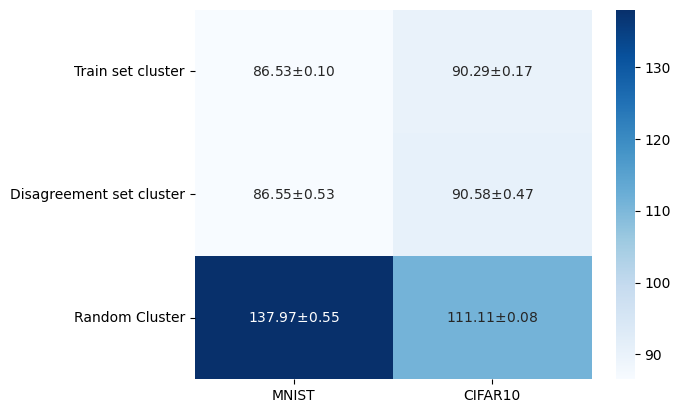

In [12]:
import seaborn as sn
import matplotlib.pyplot as plt

sn.heatmap(pd.DataFrame(zero_val_heatmap, columns=['MNIST', 'CIFAR10'], index=['Train set cluster', 'Disagreement set cluster', 'Random Cluster']), annot=zero_val_clusters, fmt="", cmap="Blues")

plt.savefig("./results/heatmap_partition_based_bounds_01.pdf", bbox_inches='tight')

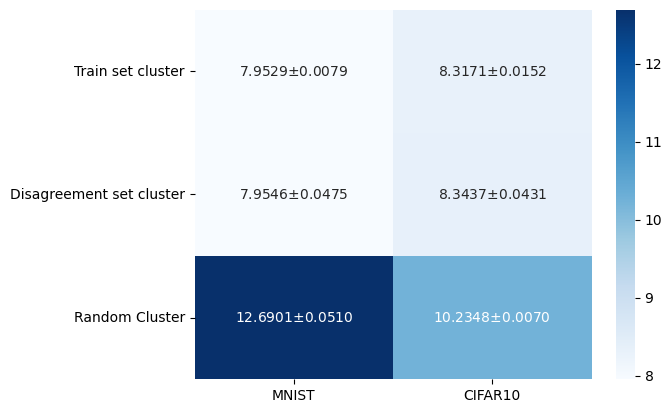

In [13]:
sn.heatmap(pd.DataFrame(CE_val_heatmap, columns=['MNIST', 'CIFAR10'], index=['Train set cluster', 'Disagreement set cluster', 'Random Cluster']), annot=CE_val_clusters, fmt="", cmap="Blues")
plt.savefig("./results/heatmap_partition_based_bounds_CE.pdf", bbox_inches='tight')
